In [1]:
import mdtraj as md

# MDAnalysis

In [1]:
import MDAnalysis as mda
from MDAnalysis.analysis.waterdynamics import WaterOrientationalRelaxation as WOR
import matplotlib.pyplot as plt

/home/ubuntu/miniconda3/envs/temp-github/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ubuntu/miniconda3/envs/temp-github/lib/python3.8/site-packages/MDAnalysis/analysis/hbonds/hbond_autocorrel.py:52: DeprecationWarning: This module was moved to MDAnalysis.analysis.hydrogenbonds.hbond_autocorrel; hbonds.hbond_autocorrel will be removed in 3.0.0.
  warnings.warn(wmsg, category=DeprecationWarning)


`WARNING:` change the trajectory with one that I have property of (from EPFL??)

In [2]:
# Load your trajectory and topology files
u = mda.Universe('/home/ubuntu/temp-github/molecular-modeling-kit/water-entropy/example_trajs/0.pdb', '/home/ubuntu/temp-github/molecular-modeling-kit/water-entropy/example_trajs/traj.dcd')

/home/ubuntu/miniconda3/envs/temp-github/lib/python3.8/site-packages/MDAnalysis/topology/PDBParser.py:287: UserWarning: PDB file is missing resid information.  Defaulted to '1'
  warnings.warn("PDB file is missing resid information.  "
/home/ubuntu/miniconda3/envs/temp-github/lib/python3.8/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


In [3]:
# Select water molecules
# selection = 'resname WAT'
# selection = "byres name OH2 and sphzone 6.0 protein and resid 42"
selection = "resname WAT and resid 2774"


# Compute the WOR for waters within 3 Ang of each atom, in order to see if there is a portion of the protein which is particularly favorable to interactions with water molecules

In [4]:
selection_waters_around_ligand = "byres resname WAT and around 4 resname LIG"  # I use 4 Ang because if I used 3, it would end up being trivial, it's just a measure of how many water bridges you have around the ligand
waters_around_ligand = u.select_atoms(selection_waters_around_ligand)
ligand = u.select_atoms('resname LIG')

In [6]:
for atom_name in ligand.names:
    print(atom_name)

H1
H2
H3
H4
H5
H6
H7
H8
H9
H10
H11
H12
H13
H14
H15
H16
H17
H18
H19
H20
H21
H22
H23
H24
H25
H26
H27
H28
H29
O1
F1
N1
N2
C1
C2
C3
C4
C5
C6
C7
C8
C9
C10
C11
C12
C13
C14
C15
C16
C17
N3
N4
C18
C19
C20
C21
C22
C23
C24
C25
C26
N5


In [10]:
atom_name = ligand.names[0]
waters_selection = f"byres resname WAT and around 4 (resname LIG and name {atom_name})"


In [12]:
u.select_atoms(waters_selection)

<AtomGroup with 15 atoms>

In [21]:
atom_name = ligand.names[0]

In [22]:
waters_selection = f"byres resname WAT and around 4 (resname LIG and name {atom_name})"

In [23]:
WOR_analysis = WOR(u, waters_selection, 0, 300, 20)

In [24]:
WOR_analysis.run()

100%|██████████| 300/300 [00:01<00:00, 162.68it/s]


In [43]:
ligand.names

array(['H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'H7', 'H8', 'H9', 'H10', 'H11',
       'H12', 'H13', 'H14', 'H15', 'H16', 'H17', 'H18', 'H19', 'H20',
       'H21', 'H22', 'H23', 'H24', 'H25', 'H26', 'H27', 'H28', 'H29',
       'O1', 'F1', 'N1', 'N2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7',
       'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'C15', 'C16', 'C17',
       'N3', 'N4', 'C18', 'C19', 'C20', 'C21', 'C22', 'C23', 'C24', 'C25',
       'C26', 'N5'], dtype=object)

In [51]:
for atom_name in ligand.names:
    # waters_selection = f"same residue as (resname WAT and around 4 (resname LIG and name {atom_name}))"  # "same residue as" doesn't work for some reason. In some cases, it returns thousands of atoms and I don't understand
    waters_selection = f"(resname WAT and around 4 (resname LIG and name {atom_name}))"
    m = u.select_atoms(waters_selection)
    print(f'{atom_name=}, {m.n_atoms=}')

atom_name='H1', m.n_atoms=5
atom_name='H2', m.n_atoms=7
atom_name='H3', m.n_atoms=7
atom_name='H4', m.n_atoms=12
atom_name='H5', m.n_atoms=3
atom_name='H6', m.n_atoms=4
atom_name='H7', m.n_atoms=1
atom_name='H8', m.n_atoms=3
atom_name='H9', m.n_atoms=7
atom_name='H10', m.n_atoms=5
atom_name='H11', m.n_atoms=1
atom_name='H12', m.n_atoms=0
atom_name='H13', m.n_atoms=0
atom_name='H14', m.n_atoms=0
atom_name='H15', m.n_atoms=0
atom_name='H16', m.n_atoms=8
atom_name='H17', m.n_atoms=6
atom_name='H18', m.n_atoms=13
atom_name='H19', m.n_atoms=1
atom_name='H20', m.n_atoms=7
atom_name='H21', m.n_atoms=3
atom_name='H22', m.n_atoms=1
atom_name='H23', m.n_atoms=8
atom_name='H24', m.n_atoms=8
atom_name='H25', m.n_atoms=8
atom_name='H26', m.n_atoms=9
atom_name='H27', m.n_atoms=7
atom_name='H28', m.n_atoms=9
atom_name='H29', m.n_atoms=5
atom_name='O1', m.n_atoms=7
atom_name='F1', m.n_atoms=11
atom_name='N1', m.n_atoms=0
atom_name='N2', m.n_atoms=3
atom_name='C1', m.n_atoms=6
atom_name='C2', m.n_atoms

In [48]:
m.n_atoms

6

In [20]:
# for atom_name in ligand.names:
    atom_name = ligand.names[0]
    waters_selection = f"byres resname WAT and around 4 (resname LIG and name {atom_name})"
    WOR_analysis = WOR(u, waters_selection, 0, 300, 20)
    WOR_analysis.run()
    #now, if we want, we can plot our data
    plt.figure(1,figsize=(18, 6))
    #WOR OH
    plt.subplot(131)
    plt.xlabel('time')
    plt.ylabel('WOR')
    plt.title('WOR OH')
    plt.plot(range(0,len(WOR_analysis.timeseries)),[column[0] for column in WOR_analysis.timeseries])
    #WOR HH
    plt.subplot(132)
    plt.xlabel('time')
    plt.ylabel('WOR')
    plt.title('WOR HH')
    plt.plot(range(0,len(WOR_analysis.timeseries)),[column[1] for column in WOR_analysis.timeseries])
    #WOR dip
    plt.subplot(133)
    plt.xlabel('time')
    plt.ylabel('WOR')
    plt.title('WOR dip')
    plt.plot(range(0,len(WOR_analysis.timeseries)),[column[2] for column in WOR_analysis.timeseries])
    plt.show()

100%|██████████| 300/300 [00:01<00:00, 160.27it/s]


KeyboardInterrupt: 

100%|██████████| 300/300 [00:01<00:00, 177.97it/s]


ValueError: x and y must have same first dimension, but have shapes (0,) and (20,)

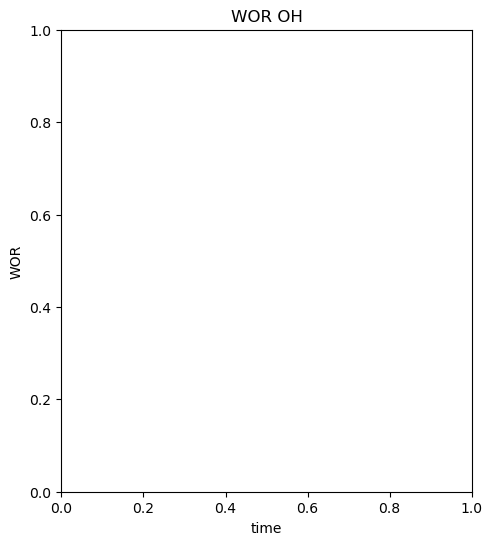

In [5]:
for atom_name in ligand.names:
    waters_selection = f"byres resname WAT and around 4 (resname LIG and {atom_name})"
    WOR_analysis = WOR(u, selection, 0, 300, 20)
    WOR_analysis.run()
    time = 0
    #now, if we want, we can plot our data
    plt.figure(1,figsize=(18, 6))
    #WOR OH
    plt.subplot(131)
    plt.xlabel('time')
    plt.ylabel('WOR')
    plt.title('WOR OH')
    plt.plot(range(0,time),[column[0] for column in WOR_analysis.timeseries])
    #WOR HH
    plt.subplot(132)
    plt.xlabel('time')
    plt.ylabel('WOR')
    plt.title('WOR HH')
    plt.plot(range(0,time),[column[1] for column in WOR_analysis.timeseries])
    #WOR dip
    plt.subplot(133)
    plt.xlabel('time')
    plt.ylabel('WOR')
    plt.title('WOR dip')
    plt.plot(range(0,time),[column[2] for column in WOR_analysis.timeseries])
    plt.show()

In [75]:
ligand.names

array(['H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'H7', 'H8', 'H9', 'H10', 'H11',
       'H12', 'H13', 'H14', 'H15', 'H16', 'H17', 'H18', 'H19', 'H20',
       'H21', 'H22', 'H23', 'H24', 'H25', 'H26', 'H27', 'H28', 'H29',
       'O1', 'F1', 'N1', 'N2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7',
       'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'C15', 'C16', 'C17',
       'N3', 'N4', 'C18', 'C19', 'C20', 'C21', 'C22', 'C23', 'C24', 'C25',
       'C26', 'N5'], dtype=object)

In [9]:
WOR_analysis = WOR(u, selection, 0, 300, 20)
WOR_analysis.run()


100%|██████████| 300/300 [00:01<00:00, 298.43it/s]


In [11]:
time = 0

#now we print the data ready to plot. The first two columns are WOR_OH vs t plot,
#the second two columns are WOR_HH vs t graph and the third two columns are WOR_dip vs t graph
for WOR_OH, WOR_HH, WOR_dip in WOR_analysis.timeseries:
      print("{time} {WOR_OH} {time} {WOR_HH} {time} {WOR_dip}".format(time=time, WOR_OH=WOR_OH, WOR_HH=WOR_HH,WOR_dip=WOR_dip))
      time += 1


0 0.04139641352712245 0 0.03166096627376661 0 0.024698955929301682
1 -0.03970539148418559 1 0.033263833897417765 1 0.050167532391706855
2 -0.014168821876004978 2 -0.015459208298167609 2 0.038005673135465295
3 0.11086649413608325 3 0.04897908112413083 3 0.03755106627618142
4 0.002158951033602347 4 0.04969462222624854 4 -0.02069184212588651
5 0.0009467145615022227 5 -0.0684894233179694 5 -0.039732335640458416
6 -0.04268734296387336 6 -0.08827499545732562 6 0.005019205527978245
7 -0.09678014517204805 7 0.08042027086173494 7 0.007941961512854485
8 -0.16191289430598924 8 -0.1268616061125537 8 -0.00042552207158606803
9 -0.08817266151792966 9 0.009132429612763377 9 0.0720321031191665
10 0.03995729204430877 10 -0.030416515150880414 10 -0.060718628146108906
11 0.18496273541815259 11 0.1745586718325254 11 0.023892035183338184
12 -0.01814105281977678 12 -0.058563491226379376 12 -0.09837016878716956
13 0.11744497747679168 13 -0.04518921132640499 13 -0.123570432115867
14 0.1175952086983787 14 0.008

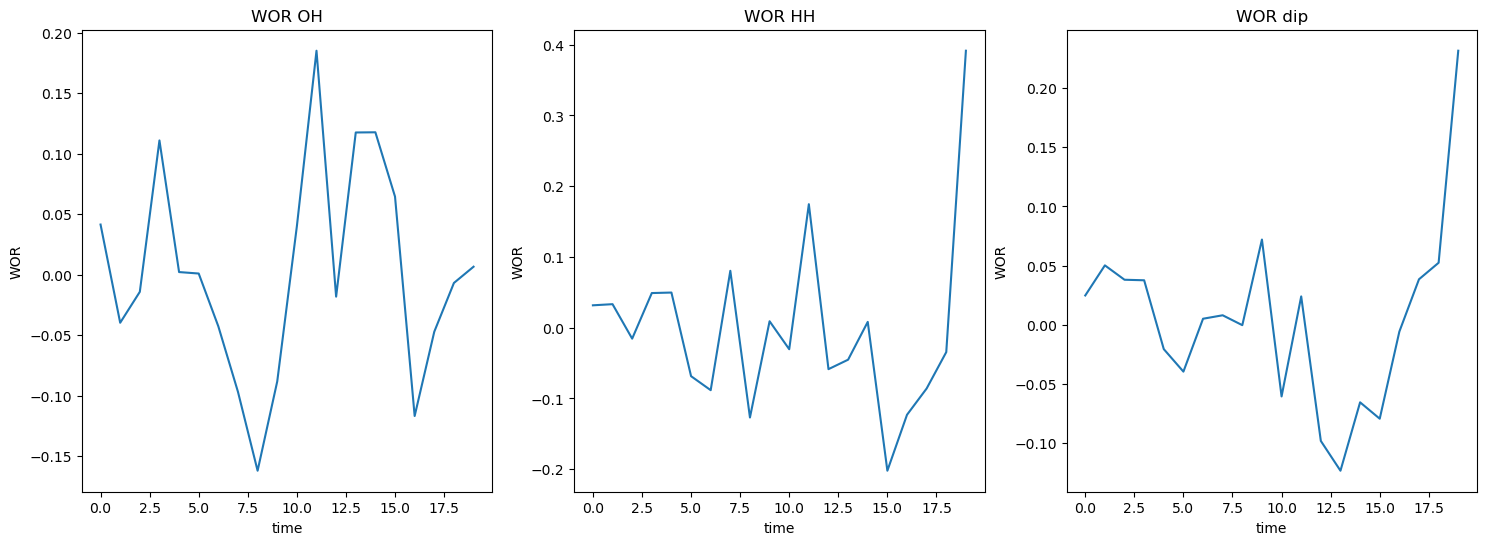

In [12]:
#now, if we want, we can plot our data
plt.figure(1,figsize=(18, 6))

#WOR OH
plt.subplot(131)
plt.xlabel('time')
plt.ylabel('WOR')
plt.title('WOR OH')
plt.plot(range(0,time),[column[0] for column in WOR_analysis.timeseries])

#WOR HH
plt.subplot(132)
plt.xlabel('time')
plt.ylabel('WOR')
plt.title('WOR HH')
plt.plot(range(0,time),[column[1] for column in WOR_analysis.timeseries])

#WOR dip
plt.subplot(133)
plt.xlabel('time')
plt.ylabel('WOR')
plt.title('WOR dip')
plt.plot(range(0,time),[column[2] for column in WOR_analysis.timeseries])

plt.show()

In [14]:
#now, if we want, we can plot our data
plt.figure(1,figsize=(18, 6))

#WOR OH
plt.subplot(131)
plt.xlabel('time')
plt.ylabel('WOR')
plt.title('WOR OH')
plt.plot(range(0,time),[column[0] for column in WOR_analysis.timeseries])

#WOR HH
plt.subplot(132)
plt.xlabel('time')
plt.ylabel('WOR')
plt.title('WOR HH')
plt.plot(range(0,time),[column[1] for column in WOR_analysis.timeseries])

#WOR dip
plt.subplot(133)
plt.xlabel('time')
plt.ylabel('WOR')
plt.title('WOR dip')
plt.plot(range(0,time),[column[2] for column in WOR_analysis.timeseries])

plt.show()

In [ ]:
u.

In [14]:
# Create the WaterOrientationalRelaxation object
wor = WOR(u, selection, 0, 100, 20)

In [15]:
# Run the analysis
wor.run()


100%|██████████| 300/300 [00:01<00:00, 290.16it/s]


In [19]:
len(wor.timeseries)

20

In [16]:
# Plot the orientational correlation function
time = wor.times
correlation = wor.COH

plt.plot(time, correlation)
plt.xlabel('Time (ps)')
plt.ylabel('Orientational Correlation Function')
plt.title('Orientational Relaxation of Water')
plt.show()


AttributeError: 'WaterOrientationalRelaxation' object has no attribute 'times'

## Public MD trajectories + water rotational dynamics near ligand

This section downloads a lightweight trajectory from the internet and computes water orientational relaxation (WOR), following the MDAnalysis waterdynamics example.

Default dataset:
- `ifabp_water` from `MDAnalysisData` (~74 MB, 500 frames, explicit water)

You can switch to other datasets later if needed.

In [ ]:
# If needed, uncomment the next line:
# %pip install -q MDAnalysis MDAnalysisData waterdynamics matplotlib

In [ ]:
import MDAnalysis as mda
import matplotlib.pyplot as plt
from MDAnalysisData import datasets
from waterdynamics import WaterOrientationalRelaxation as WOR

In [ ]:
# Download a not-too-heavy trajectory from the internet.
# I-FABP includes explicit water and is suitable for this analysis.
ds = datasets.fetch_ifabp_water()
u = mda.Universe(ds.topology, ds.trajectory)
print(f'Loaded {u.trajectory.n_frames} frames and {u.atoms.n_atoms} atoms')

In [ ]:
# Detect common water names and choose the oxygen atom label used in this topology.
water_resnames = ["HOH", "WAT", "SOL", "TIP3"]
water_ag = u.select_atoms("resname " + " ".join(water_resnames))
if water_ag.n_atoms == 0:
    raise ValueError("No water molecules found with common names HOH/WAT/SOL/TIP3")

oxygen_name_candidates = ["OH2", "OW", "O"]
oxygen_name = None
for name in oxygen_name_candidates:
    if water_ag.select_atoms(f"name {name}").n_atoms > 0:
        oxygen_name = name
        break
if oxygen_name is None:
    raise ValueError("Could not find a water oxygen atom name among OH2/OW/O")

# Try to find a ligand-like residue (non-protein, non-ion, non-water).
ligand_exclusion = "protein or nucleic or resname HOH WAT SOL TIP3 NA CL K CA MG ZN"
ligand_like = u.select_atoms(f"not ({ligand_exclusion})")

if ligand_like.n_atoms > 0:
    ligand_residue = max(ligand_like.residues, key=lambda r: r.atoms.n_atoms)
    target_selection = f"resid {ligand_residue.resid} and segid {ligand_residue.segid}" if ligand_residue.segid else f"resid {ligand_residue.resid}"
    target_label = f"ligand-like residue: {ligand_residue.resname} {ligand_residue.resid}"
else:
    # Fallback: use whole protein as reference if no ligand is present.
    target_selection = "protein"
    target_label = "protein (fallback; no ligand-like residue detected)"

radius_ang = 4.0
wor_selection = f"byres (resname {' '.join(water_resnames)} and name {oxygen_name} and around {radius_ang} ({target_selection}))"
print("Target:", target_label)
print("WOR selection:", wor_selection)
print("Selected water oxygen atoms:", u.select_atoms(wor_selection).n_atoms)

In [ ]:
# Run WaterOrientationalRelaxation as in the waterdynamics example.
start = 0
stop = min(300, u.trajectory.n_frames - 1)
dtmax = min(20, max(5, stop // 10))

wor = WOR(u, wor_selection, start, stop, dtmax)
wor.run()

times = list(range(len(wor.timeseries)))
wor_oh = [v[0] for v in wor.timeseries]
wor_hh = [v[1] for v in wor.timeseries]
wor_dip = [v[2] for v in wor.timeseries]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
axes[0].plot(times, wor_oh)
axes[0].set_title("WOR OH")
axes[0].set_xlabel("window index")
axes[0].set_ylabel("C(t)")

axes[1].plot(times, wor_hh)
axes[1].set_title("WOR HH")
axes[1].set_xlabel("window index")
axes[1].set_ylabel("C(t)")

axes[2].plot(times, wor_dip)
axes[2].set_title("WOR dipole")
axes[2].set_xlabel("window index")
axes[2].set_ylabel("C(t)")

plt.show()
print(f"Computed WOR with start={start}, stop={stop}, dtmax={dtmax}, points={len(times)}")

In [1]:
import MDAnalysis as mda
import matplotlib.pyplot as plt
from MDAnalysisData import datasets
from waterdynamics import WaterOrientationalRelaxation as WOR

/Users/aprunotto/Documents/alessio-code/molecular-modeling-kit/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = datasets.fetch_ifabp_water()
u = mda.Universe(ds.topology, ds.trajectory)
print(f'Loaded {u.trajectory.n_frames} frames and {u.atoms.n_atoms} atoms')

water_resnames = ["HOH", "WAT", "SOL", "TIP3"]
water_ag = u.select_atoms("resname " + " ".join(water_resnames))
if water_ag.n_atoms == 0:
    raise ValueError("No water molecules found with common names HOH/WAT/SOL/TIP3")

oxygen_name = None
for name in ["OH2", "OW", "O"]:
    if water_ag.select_atoms(f"name {name}").n_atoms > 0:
        oxygen_name = name
        break
if oxygen_name is None:
    raise ValueError("Could not find water oxygen atom name among OH2/OW/O")

ligand_exclusion = "protein or nucleic or resname HOH WAT SOL TIP3 NA CL K CA MG ZN"
ligand_like = u.select_atoms(f"not ({ligand_exclusion})")

if ligand_like.n_atoms > 0:
    ligand_residue = max(ligand_like.residues, key=lambda r: r.atoms.n_atoms)
    target_selection = f"resid {ligand_residue.resid} and segid {ligand_residue.segid}" if ligand_residue.segid else f"resid {ligand_residue.resid}"
    target_label = f"ligand-like residue: {ligand_residue.resname} {ligand_residue.resid}"
else:
    target_selection = "protein"
    target_label = "protein (fallback; no ligand-like residue detected)"

wor_selection = f"byres (resname {' '.join(water_resnames)} and name {oxygen_name} and around 4.0 ({target_selection}))"
print("Target:", target_label)
print("WOR selection:", wor_selection)
print("Selected water oxygen atoms:", u.select_atoms(wor_selection).n_atoms)

ifabp_water.psf: 2.19MB [00:00, 3.25MB/s]                            
ifabp_water_0.pdb: 958kB [00:00, 1.82MB/s]                            
rmsfit_ifabp_water_1.dcd: 74.7MB [00:02, 27.7MB/s]                              
/Users/aprunotto/Documents/alessio-code/molecular-modeling-kit/.venv/lib/python3.14/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Loaded 500 frames and 12445 atoms
Target: protein (fallback; no ligand-like residue detected)
WOR selection: byres (resname HOH WAT SOL TIP3 and name OH2 and around 4.0 (protein))
Selected water oxygen atoms: 2367


100%|██████████| 500/500 [00:08<00:00, 61.28it/s]


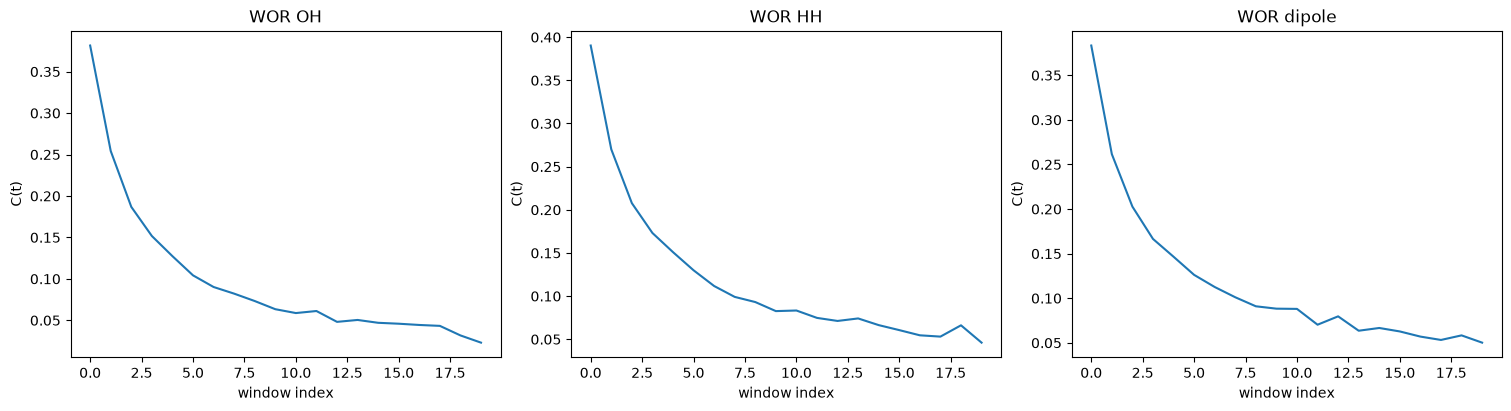

Computed WOR with start=0, stop=300, dtmax=20, points=20


In [3]:
start = 0
stop = min(300, u.trajectory.n_frames - 1)
dtmax = min(20, max(5, stop // 10))

wor = WOR(u, wor_selection, start, stop, dtmax)
wor.run()

times = list(range(len(wor.timeseries)))
wor_oh = [v[0] for v in wor.timeseries]
wor_hh = [v[1] for v in wor.timeseries]
wor_dip = [v[2] for v in wor.timeseries]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
axes[0].plot(times, wor_oh)
axes[0].set_title("WOR OH")
axes[0].set_xlabel("window index")
axes[0].set_ylabel("C(t)")

axes[1].plot(times, wor_hh)
axes[1].set_title("WOR HH")
axes[1].set_xlabel("window index")
axes[1].set_ylabel("C(t)")

axes[2].plot(times, wor_dip)
axes[2].set_title("WOR dipole")
axes[2].set_xlabel("window index")
axes[2].set_ylabel("C(t)")

plt.show()
print(f"Computed WOR with start={start}, stop={stop}, dtmax={dtmax}, points={len(times)}")

## Public protein-ligand trajectory (strict ligand-centered WOR)

This section uses the public ProLIF trajectory files and computes WOR for waters selected **strictly around ligand atoms** (`resname LIG`).

- No protein-centered fallback is used.
- The analysis fails if no ligand or no ligand-centered waters are found.

Topology: /Users/aprunotto/Documents/alessio-code/molecular-modeling-kit/water-entropy/notebooks/public_datasets/prolif/water_m2.pdb (5.23 MB)
Trajectory: /Users/aprunotto/Documents/alessio-code/molecular-modeling-kit/water-entropy/notebooks/public_datasets/prolif/water_m2.xtc (3.82 MB)
Loaded universe: 52323 atoms, 20 frames
Top non-protein/non-water residues by atom count:
  QNB 1: 49 atoms
Selected ligand residue: QNB 1 (49 atoms)
Ligand-centered shell atom count (frame 0): 21
Ligand-centered shell water residues (frame 0): 7


100%|██████████| 20/20 [00:00<00:00, 602.73it/s]


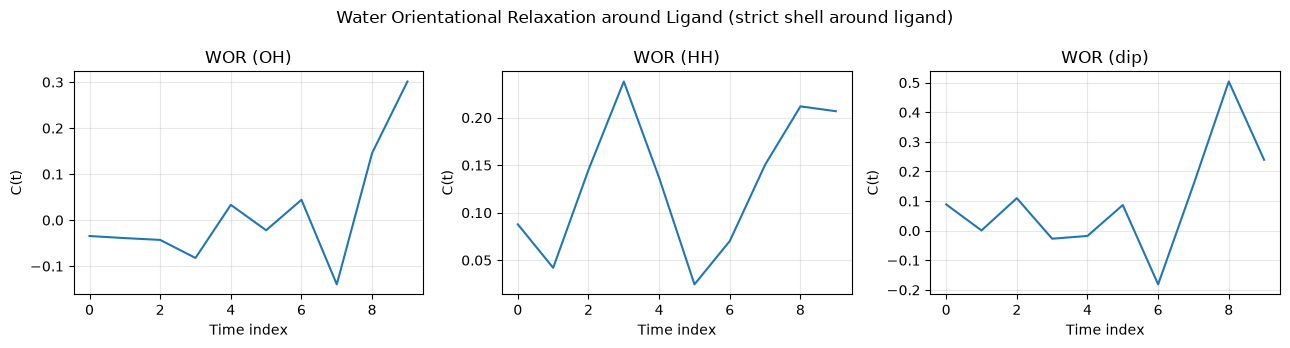

Computed 10 WOR points (start=0, stop=20, dtmax=10).


In [8]:
from pathlib import Path
from urllib.request import urlretrieve
import MDAnalysis as mda
from waterdynamics import WaterOrientationalRelaxation as WOR
import matplotlib.pyplot as plt

base_url = "https://raw.githubusercontent.com/chemosim-lab/ProLIF/master/prolif/data"
out_dir = Path.cwd() / "public_datasets" / "prolif"
out_dir.mkdir(parents=True, exist_ok=True)

top_path = out_dir / "water_m2.pdb"
traj_path = out_dir / "water_m2.xtc"

for url, path in [
    (f"{base_url}/water_m2.pdb", top_path),
    (f"{base_url}/water_m2.xtc", traj_path),
]:
    if not path.exists() or path.stat().st_size == 0:
        print(f"Downloading {url} -> {path}")
        urlretrieve(url, path)

print(f"Topology: {top_path} ({top_path.stat().st_size / 1e6:.2f} MB)")
print(f"Trajectory: {traj_path} ({traj_path.stat().st_size / 1e6:.2f} MB)")

u_lig = mda.Universe(str(top_path), str(traj_path))
print(f"Loaded universe: {u_lig.atoms.n_atoms} atoms, {len(u_lig.trajectory)} frames")

# Strict ligand identification: pick the largest residue among non-protein, non-water, non-common-ion residues.
ligand_pool = u_lig.select_atoms(
    "not protein and not resname HOH WAT SOL TIP3 TIP4 TIP5 TIP3P NA CL K CA MG ZN"
)
if ligand_pool.n_atoms == 0:
    raise ValueError(
        "Strict ligand-centered WOR requested, but no non-protein/non-water ligand candidates were found."
    )

candidate_residues = sorted(ligand_pool.residues, key=lambda r: r.atoms.n_atoms, reverse=True)
ligand_res = candidate_residues[0]
ligand = ligand_res.atoms

print("Top non-protein/non-water residues by atom count:")
for res in candidate_residues[:5]:
    print(f"  {res.resname} {res.resid}: {res.atoms.n_atoms} atoms")
print(f"Selected ligand residue: {ligand_res.resname} {ligand_res.resid} ({ligand.n_atoms} atoms)")

# Build a strict ligand-shell water set at frame 0, then freeze it as an index selection for WOR.
water_oxy_expr = "resname HOH WAT SOL TIP3 TIP4 TIP5 TIP3P and name O OW OH2"
shell_expr = f"byres ({water_oxy_expr} and around 4.0 group ligand)"
water_lig_shell = u_lig.select_atoms(shell_expr, ligand=ligand)

print(f"Ligand-centered shell atom count (frame 0): {water_lig_shell.n_atoms}")
print(f"Ligand-centered shell water residues (frame 0): {len(water_lig_shell.residues)}")

if water_lig_shell.n_atoms == 0:
    raise ValueError(
        "Strict ligand-centered WOR selection is empty. "
        "No waters matched within 4.0 A around the ligand atoms."
    )

wor_selection = "index " + " ".join(map(str, water_lig_shell.indices))

start, stop, dtmax = 0, min(300, len(u_lig.trajectory)), 20
if stop - start <= dtmax:
    dtmax = max(5, (stop - start) // 2)

wor_ligand = WOR(u_lig, wor_selection, start, stop, dtmax)
wor_ligand.run()

times = list(range(len(wor_ligand.timeseries)))
wor_oh = [x[0] for x in wor_ligand.timeseries]
wor_hh = [x[1] for x in wor_ligand.timeseries]
wor_dip = [x[2] for x in wor_ligand.timeseries]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharex=True)
for ax, y, label in zip(axes, [wor_oh, wor_hh, wor_dip], ["OH", "HH", "dip"]):
    ax.plot(times, y)
    ax.set_title(f"WOR ({label})")
    ax.set_xlabel("Time index")
    ax.set_ylabel("C(t)")
    ax.grid(alpha=0.3)

fig.suptitle("Water Orientational Relaxation around Ligand (strict shell around ligand)")
fig.tight_layout()
plt.show()

print(f"Computed {len(times)} WOR points (start={start}, stop={stop}, dtmax={dtmax}).")